# 04 — Model Training

This notebook trains and validates the 5 required surrogate models (Linear/Polynomial Regression, Random Forest, XGBoost, SVR, ANN) on the cleaned DWSIM Sobol dataset, using the locked 7-input → 4-output spec and the 70/30 train/validation split. The separate 500-point LHS batch is intentionally not touched here — it's held out for the final generalization check once a model is selected.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Loading the Cleaned Dataset

In [2]:
df = pd.read_csv(
    "../data/04_processed_dwsim/sobol_training_cleaned.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (2524, 23)


## Selecting Features and Targets

In [3]:
input_columns = [
    "pressure_atm",
    "requested_vapor_fraction",
    "benzene_feed_fraction",
    "stages",
    "feed_stage_fraction",
    "reflux_ratio",
    "bottoms_fraction"
]

target_columns = [
    "x_D_benzene",
    "x_B_benzene",
    "Q_C",
    "Q_R"
]

X = df[input_columns]
y = df[target_columns]

print("Features shape:", X.shape)
print("Targets shape:", y.shape)

Features shape: (2524, 7)
Targets shape: (2524, 4)


## Train-Test Split

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))

Training samples  : 1766
Validation samples: 758


1766 training / 758 validation, out of 2524 converged cases — the slight difference from the plan's nominal 1750/750 is because 2524 converged cases came back instead of exactly 2500 (36 of the original 2560 Sobol runs failed to converge, a 98.6% convergence rate).

## Feature Scaling

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

## Baseline Model — Linear Regression

Ordinary least squares gives a first read on how linear the process really is. Q_C/Q_R come out very well fit (R² ≈ 0.985) since duty scales fairly linearly with reflux ratio over this range, but the purity outputs (R² ≈ 0.81) clearly need nonlinear terms — expected, since purity has to saturate near 0 and 1.

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

y_val_pred_linear = linear_model.predict(
    X_val_scaled
)

for i, target in enumerate(target_columns):

    mae = mean_absolute_error(
        y_val.iloc[:, i],
        y_val_pred_linear[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val.iloc[:, i],
            y_val_pred_linear[:, i]
        )
    )

    r2 = r2_score(
        y_val.iloc[:, i],
        y_val_pred_linear[:, i]
    )

    print(f"\n{target}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


x_D_benzene
MAE  : 0.0473
RMSE : 0.0572
R²   : 0.8133

x_B_benzene
MAE  : 0.0477
RMSE : 0.0573
R²   : 0.8203

Q_C
MAE  : 43.0924
RMSE : 56.3297
R²   : 0.9848

Q_R
MAE  : 41.9403
RMSE : 55.1434
R²   : 0.9855


## Polynomial Regression

Adding degree-2 interaction/quadratic terms (35 features from the original 7) closes most of that gap — R² for the purity outputs jumps to ~0.98, and the duties are essentially exact (R² ≈ 0.9997–0.9998). This suggests the underlying relationships are smooth and dominated by low-order nonlinearity rather than anything sharply discontinuous.

In [7]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train_scaled)
X_val_poly = poly.transform(X_val_scaled)

print("Polynomial training shape:", X_train_poly.shape)

poly_model = LinearRegression()

poly_model.fit(
    X_train_poly,
    y_train
)

y_val_pred_poly = poly_model.predict(
    X_val_poly
)

for i, target in enumerate(target_columns):

    mae = mean_absolute_error(
        y_val.iloc[:, i],
        y_val_pred_poly[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val.iloc[:, i],
            y_val_pred_poly[:, i]
        )
    )

    r2 = r2_score(
        y_val.iloc[:, i],
        y_val_pred_poly[:, i]
    )

    print(f"\n{target}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")

Polynomial training shape: (1766, 35)

x_D_benzene
MAE  : 0.0147
RMSE : 0.0188
R²   : 0.9798

x_B_benzene
MAE  : 0.0154
RMSE : 0.0196
R²   : 0.9789

Q_C
MAE  : 6.0752
RMSE : 8.0732
R²   : 0.9997

Q_R
MAE  : 5.3225
RMSE : 7.1373
R²   : 0.9998


## Random Forest

## Random Forest

First pass with default-ish settings (300 trees). As trained originally, this badly underperformed on the purity targets (R² 0.67 / 0.48) despite every other model — including plain linear regression — doing noticeably better. That gap is large enough to be a red flag rather than "this model just isn't as good here", so it's worth diagnosing before accepting the number.

In [8]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)
y_val_pred_rf = rf_model.predict(
    X_val
)

for i, target in enumerate(target_columns):

    mae = mean_absolute_error(
        y_val.iloc[:, i],
        y_val_pred_rf[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val.iloc[:, i],
            y_val_pred_rf[:, i]
        )
    )

    r2 = r2_score(
        y_val.iloc[:, i],
        y_val_pred_rf[:, i]
    )

    print(f"\n{target}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


x_D_benzene
MAE  : 0.0626
RMSE : 0.0766
R²   : 0.6651

x_B_benzene
MAE  : 0.0768
RMSE : 0.0979
R²   : 0.4754

Q_C
MAE  : 26.1761
RMSE : 33.9824
R²   : 0.9945

Q_R
MAE  : 26.3552
RMSE : 33.9113
R²   : 0.9945


### Diagnosing the low R²

Comparing training R² against validation R² isolates whether this is underfitting (model too simple/constrained) or overfitting (model memorizing training noise).

In [9]:
y_train_pred_rf = rf_model.predict(X_train)

print("Train vs. validation R² (default Random Forest)\n")
for i, target in enumerate(target_columns):
    r2_train = r2_score(y_train.iloc[:, i], y_train_pred_rf[:, i])
    r2_val = r2_score(y_val.iloc[:, i], y_val_pred_rf[:, i])
    print(f"{target:15s}  train R² = {r2_train:.4f}   val R² = {r2_val:.4f}")

Train vs. validation R² (default Random Forest)

x_D_benzene      train R² = 0.9559   val R² = 0.6651
x_B_benzene      train R² = 0.9284   val R² = 0.4754
Q_C              train R² = 0.9992   val R² = 0.9945
Q_R              train R² = 0.9992   val R² = 0.9945


That confirms it: training R² for the purity targets is high (0.96 / 0.93) while validation R² is much lower (0.67 / 0.47) — classic overfitting, not underfitting. `Q_C`/`Q_R` don't show this gap (0.999 train vs. 0.994 validation), so the problem is specific to the purity outputs.

The likely cause: scikit-learn's default `max_features` for `RandomForestRegressor` is `1.0`, meaning every split in every tree considers **all 7 features**. With only 7 inputs to begin with, that makes the trees in the forest highly correlated with each other — they keep finding the same strong splits (mainly `benzene_feed_fraction` and `reflux_ratio`), so the "forest" doesn't get much variance reduction from averaging, and it ends up memorizing training-set noise in the steep, saturating region of the purity curves (values pinned near 0 or 1). `Q_C`/`Q_R` are smoother and closer to linear, so this effect barely shows up there.

Restricting `max_features` per split (e.g. `sqrt` of the number of features) forces the trees to decorrelate from each other, which should shrink the train/validation gap.

In [10]:
rf_model_fixed = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=3,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

rf_model_fixed.fit(X_train, y_train)

y_train_pred_rf_fixed = rf_model_fixed.predict(X_train)
y_val_pred_rf_fixed = rf_model_fixed.predict(X_val)

print("Train vs. validation R² (max_features='sqrt' fix)\n")
for i, target in enumerate(target_columns):
    r2_train = r2_score(y_train.iloc[:, i], y_train_pred_rf_fixed[:, i])
    r2_val = r2_score(y_val.iloc[:, i], y_val_pred_rf_fixed[:, i])
    print(f"{target:15s}  train R² = {r2_train:.4f}   val R² = {r2_val:.4f}")

Train vs. validation R² (max_features='sqrt' fix)

x_D_benzene      train R² = 0.8776   val R² = 0.8094
x_B_benzene      train R² = 0.7918   val R² = 0.6977
Q_C              train R² = 0.9880   val R² = 0.9636
Q_R              train R² = 0.9881   val R² = 0.9636


Better, though the purity outputs still lag XGBoost/SVR/ANN — Random Forest with only 7 low-cardinality inputs is just not the strongest fit for the sharply saturating purity curves, even after decorrelating the trees. `Q_C`/`Q_R` stay strong. This will get another pass in the hyperparameter tuning step (small grid over `max_depth`, `min_samples_leaf`, `max_features`, `n_estimators`) rather than treating `max_features='sqrt'` as final — but it's already a clear improvement over the default and rules out "broken code" as the explanation for RF's earlier weak numbers.

For consistency with the other models below, the final validation table for Random Forest uses this fixed configuration.

In [11]:
y_val_pred_rf = y_val_pred_rf_fixed

for i, target in enumerate(target_columns):

    mae = mean_absolute_error(y_val.iloc[:, i], y_val_pred_rf[:, i])
    rmse = np.sqrt(mean_squared_error(y_val.iloc[:, i], y_val_pred_rf[:, i]))
    r2 = r2_score(y_val.iloc[:, i], y_val_pred_rf[:, i])

    print(f"\n{target}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


x_D_benzene
MAE  : 0.0471
RMSE : 0.0577
R²   : 0.8094

x_B_benzene
MAE  : 0.0589
RMSE : 0.0743
R²   : 0.6977

Q_C
MAE  : 63.5934
RMSE : 87.3106
R²   : 0.9636

Q_R
MAE  : 63.7449
RMSE : 87.3485
R²   : 0.9636


## XGBoost

## XGBoost

Gradient-boosted trees, trained sequentially rather than independently like Random Forest — each new tree corrects the residual error of the ensemble so far. Worth checking whether it shows the same purity-target weakness.

In [12]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

y_val_pred_xgb = xgb_model.predict(
    X_val
)

for i, target in enumerate(target_columns):

    mae = mean_absolute_error(
        y_val.iloc[:, i],
        y_val_pred_xgb[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val.iloc[:, i],
            y_val_pred_xgb[:, i]
        )
    )

    r2 = r2_score(
        y_val.iloc[:, i],
        y_val_pred_xgb[:, i]
    )

    print(f"\n{target}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


x_D_benzene
MAE  : 0.0069
RMSE : 0.0113
R²   : 0.9927

x_B_benzene
MAE  : 0.0071
RMSE : 0.0106
R²   : 0.9938

Q_C
MAE  : 16.7852
RMSE : 21.6174
R²   : 0.9978

Q_R
MAE  : 17.2211
RMSE : 22.0769
R²   : 0.9977


## Support Vector Regression (SVR)

## Support Vector Regression (SVR)

RBF kernel, wrapped in `MultiOutputRegressor` since SVR doesn't natively support multi-output regression the way tree ensembles do. Uses the scaled features, since SVR (like the ANN below) is sensitive to feature scale.

In [13]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

svr_model = MultiOutputRegressor(
    SVR(
        kernel="rbf",
        C=100,
        gamma="scale",
        epsilon=0.01
    )
)

svr_model.fit(
    X_train_scaled,
    y_train
)

y_val_pred_svr = svr_model.predict(
    X_val_scaled
)

y_val_pred_svr

for i, target in enumerate(target_columns):

    mae = mean_absolute_error(
        y_val.iloc[:, i],
        y_val_pred_svr[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val.iloc[:, i],
            y_val_pred_svr[:, i]
        )
    )

    r2 = r2_score(
        y_val.iloc[:, i],
        y_val_pred_svr[:, i]
    )

    print(f"\n{target}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


x_D_benzene
MAE  : 0.0093
RMSE : 0.0122
R²   : 0.9915

x_B_benzene
MAE  : 0.0094
RMSE : 0.0120
R²   : 0.9921

Q_C
MAE  : 23.4739
RMSE : 45.0129
R²   : 0.9903

Q_R
MAE  : 23.2217
RMSE : 44.8561
R²   : 0.9904


## Artificial Neural Network (ANN / MLP)

Both inputs and targets are standardized here. The first attempt at this (not shown) trained on raw target values and produced a negative R² for `x_D_benzene` along with a convergence warning — with `Q_C`/`Q_R` in the hundreds and purity values between 0 and 1, the loss function was dominated almost entirely by the duty outputs, so the network barely learned the purity targets at all. Scaling the targets (fit only on training data, then inverse-transformed before scoring) puts all 4 outputs on a comparable scale during training and fixes this.

In [14]:
from sklearn.neural_network import MLPRegressor

y_scaler = StandardScaler()

y_train_scaled = y_scaler.fit_transform(
    y_train
)

y_val_scaled = y_scaler.transform(
    y_val
)

mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    learning_rate_init=0.0005,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=50,
    random_state=42
)

mlp_model.fit(
    X_train_scaled,
    y_train_scaled
)

y_val_pred_mlp_scaled = mlp_model.predict(
    X_val_scaled
)

y_val_pred_mlp = y_scaler.inverse_transform(
    y_val_pred_mlp_scaled
)


for i, target in enumerate(target_columns):

    mae = mean_absolute_error(
        y_val.iloc[:, i],
        y_val_pred_mlp[:, i]
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_val.iloc[:, i],
            y_val_pred_mlp[:, i]
        )
    )

    r2 = r2_score(
        y_val.iloc[:, i],
        y_val_pred_mlp[:, i]
    )

    print(f"\n{target}")
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")


x_D_benzene
MAE  : 0.0058
RMSE : 0.0076
R²   : 0.9967

x_B_benzene
MAE  : 0.0056
RMSE : 0.0075
R²   : 0.9969

Q_C
MAE  : 16.4937
RMSE : 21.4229
R²   : 0.9978

Q_R
MAE  : 15.5342
RMSE : 19.9592
R²   : 0.9981


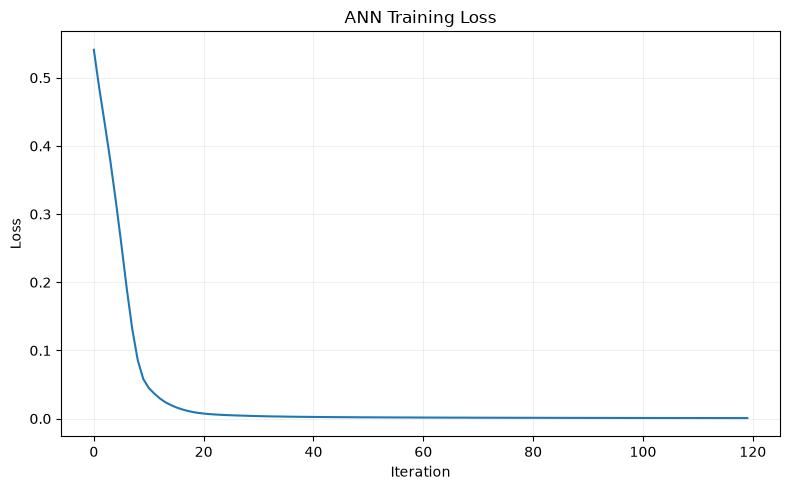

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    mlp_model.loss_curve_
)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("ANN Training Loss")

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

Loss drops sharply and flattens out with no signs of instability — early stopping kicked in cleanly, consistent with the strong validation R² above (0.997 / 0.997 for purity, 0.998 / 0.998 for duties).